# Doodle Images Classification using PyTorch

> Multi-Class Image Classification using modified LeNet architecture(Convolutional Neural Network) implemented in PyTorch.

- toc:true
- branch: master
- badges: true
- image : images/img.png
- author: Pratik Kumar
- categories: [PyTorch, CNN, PCA, t-SNE]


## **Introduction**
****
In this notebook I have implemented a modified version of LeNet-5, which is a neural network model that consists convolutional layers and was designed for classifying handwritten digit characters(MNIST). But instead of classifying the over-used handwritten digits(MNIST) dataset, we will be using the Quick Draw Doodle Datasets by Google. The dataset is present in tensorflow datasets. Hence we will be loading it from there, for which <i><b>tensorflow</b></i> latest version is required. 

The post aims to discuss and explore Multi-Class Image Classification using CNN implemented in <i><b>PyTorch</b></i> Framework. The jupyter-notebook blog post comes with direct code and output all at one place. All thanks to creators of <b>fastpages</b>!

Try Quick Draw by yourself [here](https://quickdraw.withgoogle.com)!


![](https://github.com/pr2tik1/pk-blog/blob/master/_notebooks/quick-draw/preview.jpg?raw=1)

#### Importing libraries

In [20]:
#collapse-hide
#Basic Libraries
import os
import math
import datetime
import platform
import pathlib
import random
import numpy as np
import urllib.request

#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patheffects as PathEffects
%matplotlib inline

#t-SNE
from sklearn.manifold import TSNE

#Utilities
from utilities import download, load, get_predictions, train, evaluate, epoch_time,\
                      calculate_accuracy, get_representations,get_tsne, get_pca, \
                      plot_representations

#Warnings
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

##  **Data** 
****
The <i>Quick Draw Dataset</i> is a collection of 50 million drawings across 345 categories, contributed by players of the game Quick, Draw! The bitmap dataset contains these drawings converted from vector format into <b>28x28 grayscale images</b>. The drawings were captured as timestamped vectors, tagged with metadata including what the player was asked to draw and in which country the player was located. This is available in tensorflow_datasets within 'quickdraw_bitmap'. We will be loading only <b>10</b> classes from the 345 categories.

#### Downloading Data
---
Downloading the dataset as .npy files and storing them in 'data' folder. Make sure the 'data' folder directory is not already present. In case already downloaded, comment the 'download()' function call. The dataset is quite big, downloading will however take time based upon user's internet speed. (Click to expand)

In [2]:
#collapse-hide
#download() 

#### Loading Data
---
The dataset is split into train and test of the following sizes. I have considered the following 10 classes for the purpose of Multi-Class Classification. The size of actual data is more than 30 GB. Following is a short summary about data, (Click to expand) 

In [3]:
#collapse-hide

#Function to load data into train, test and validation variables
x_train, y_train, x_valid, y_valid, test_data, test_labels, class_names = load()

#Printing the dimensions of datasets
print("\nShape of Training data(X,y): ", x_train.shape, y_train.shape)
print("Shape of Validating data(X,y): ", x_valid.shape, y_valid.shape)
print("Shape of Testing data(X,y): ", test_data.shape)
print("Classes : ",class_names) 

Loading data....
Training Data :  560000
Validating  Data :  140000
Testing  Data :  100000

Shape of Training data(X,y):  (560000, 28, 28) (560000,)
Shape of Validating data(X,y):  (140000, 28, 28) (140000,)
Shape of Testing data(X,y):  (100000, 28, 28)
Classes :  ['cloud', 'sun', 'pants', 'umbrella', 'table', 'ladder', 'eyeglasses', 'clock', 'scissors', 'cup']


#### Visualizing Data
---
Each of the images are of 28x28 dimension. Let's visualize the 10 examples from 10 classes. (Click to expand)

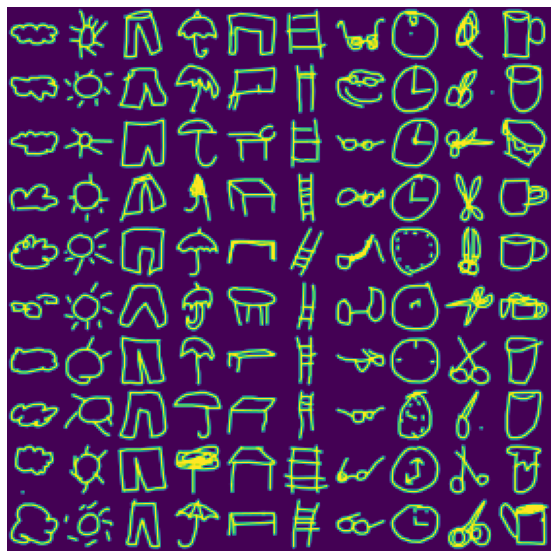

In [4]:
#collapse-hide
def visualize_classes(x_train, y_train):
    '''
    Function to visualize datasets.
    '''
    for i in range(0, 10):
        img_batch = x_train[y_train == i][0:10]
        img_batch = np.reshape(img_batch, (img_batch.shape[0]*img_batch.shape[1], img_batch.shape[2]))
        if i > 0:
            img = np.concatenate([img, img_batch], axis = 1)
        else:
            img = img_batch
    plt.figure(figsize=(10,10))
    plt.axis('off')
    plt.imshow(img)

#Visualizing train dataset
visualize_classes(x_train, y_train)

Looks like people enjoyed doodling! 😋 

#### Reshaping and Normalizing 
---
Here the following operations are carried out:
- Reshaping the data
- Normalizing the pixel values by 255
- Changing the datatype to float32

The terms and their meaning: 
- x_train : Train Input Data (NumPy Array)
- y_train : Train Labels/Output Data (NumPy Array)
- x_test : Test Input Data (NumPy Array)
- y_test : Test Labels/Output Data (NumPy Array)


In [5]:
#collapse-hide
# Reshape and normalize
x_train = x_train.reshape(x_train.shape[0], 1, 28, 28).astype('float32')
x_valid = x_valid.reshape(x_valid.shape[0], 1, 28, 28).astype('float32')
x_train /= 255.0
x_valid /= 255.0

print("Shape of training dataset ndarray: \n", x_train.shape)
print("Shape of training dataset ndarray: \n", x_valid.shape)

Shape of training dataset ndarray: 
 (560000, 1, 28, 28)
Shape of training dataset ndarray: 
 (140000, 1, 28, 28)


## **Deep Learning**
****
In this section, I have build and trained a modified version of <b>LeNet-5</b>. The original LeNet-5 architecture was developed to classify <b>MNIST Handwritten digit Images</b> by <b>Yann LeCun</b>. This architecuture is considered to be one of the pioneer architectures in deep learning era. The digit dataset and doodle dataset has similar characterstics. Both of the datasets have images in grayscale and are also available in similar dimensions (28x28 pixel dimension). To know more about Yann Lecun's work and MNIST Dataset follow [here](http://yann.lecun.com/exdb/lenet/).

For the training and predicting of classes, we import PyTorch modules, as below:

In [6]:
#collapse-hide

#Import PyTorch 
import time
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torchvision import transforms
from torchsummary import summary
from torch.utils.data import DataLoader, TensorDataset, Dataset

Initially, the numpy arrays loaded should be transformed into tensors. These tensors must be then converted into TensorDataset. Finally, these should be loaded using DataLoaders to feed them into architecture. The steps of transformation can be followed below,

* ndarray transformed to tensor(torch.tensor)
* Input(x) tensors and Output(y) tensors are merged together to form TensorDataset
* TensorDataset transformed to DataLoader



In [7]:
#collapse-hide
#Set device type to CUDA or CPU based upon availability 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )

#Train data
x_train_tensor = torch.tensor(x_train)
y_train_tensor = torch.tensor(y_train)
train_tensor = TensorDataset(x_train_tensor,y_train_tensor)

#Validation data
x_test_tensor = torch.tensor(x_valid)
y_test_tensor = torch.tensor(y_valid)
test_tensor = TensorDataset(x_test_tensor, y_test_tensor)

#DataLoaders
train_loader = DataLoader(train_tensor, batch_size= 128, num_workers=1, 
                          shuffle=True) 
test_loader = DataLoader(test_tensor, batch_size= 128, num_workers=1, 
                         shuffle=True)

device

device(type='cuda')

### Convolutinal Neural Network(CNN) Model
---
The famous LeNet architecture was first introduced by LeCun et al. in their 1998 paper, [Gradient-Based Learning Applied to Document Recognition](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf). 

![](https://github.com/pr2tik1/pk-blog/blob/master/_notebooks/quick-draw/lenet.png?raw=1)

The Multi Layered Perceptron were having following problems which was addressed by the CNNs:

- Large number of connections, as these were Fully-Connected Layers
- Only accepted vectors as inputs

CNNs addressed these issues and introduced sparse connection, direct matrices as inputs and a wide range of mathematical operations. The layers of CNN consists of image filters, pooling layers and stride operations. The LeNet architecture has two convolution layers followed by 3 linear layers or the fully connected layers. Complete layer architecture is discussed below.

#### Custom Architecture
---
Here I will be using slightly different version of LeNet. The original **LeNet-5 architecture** consists of two sets of convolutional and pooling layers, followed by a flattening layer, then two fully-connected layers and finally a gaussian connections. Our architecture does not consist the final guassian layer but a softmax layer as it is good for multi-class classification. 

Our neural network model's architecture:

- **First Layer** : The input for model is a 28×28 grayscale image which passes through the first convolutional layer with 24 feature maps or filters having size 5×5 each.

- **Second Layer**: Then this layer applies max pooling with a filter size 2×2 and a stride of two.

- **Third Layer**: Next, there is a second convolution again with 24 output channels, 5×5 kernel, and stride of 1. After this, it is further send to ReLU.

- **Fourth Layer**: The fourth layer is again an max pooling layer with filter size 2×2 and a stride of 2. 

- **Sixth Layer**: The sixth layer is a fully connected layer of dimensions (24x4×4)×50, followed by ReLU.

- Before sending it to the next layer, the tensors must be unenrolled or set to shape of a vector to push them into fully connected layers. 

- **Output Layer**: Finally, there is a fully connected softmax output layer ŷ with 50×10 dimension, followed by softmax layer. The final output layer ends with 10 output neurons because we have 10 classes to classify the dataset.

In [8]:
class CNN(nn.Module):
    def __init__(self, input_size, n_feature, output_size):
        super(CNN, self).__init__()
        self.n_feature = n_feature
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=n_feature, kernel_size=5)
        self.conv2 = nn.Conv2d(n_feature, n_feature, kernel_size=5)
        self.fc1 = nn.Linear(n_feature*4*4, 50)
        self.fc2 = nn.Linear(50, 10)
        
    def forward(self, x, verbose=False):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, kernel_size=2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, kernel_size=2)
        x = x.view(-1, self.n_feature*4*4)
        x = F.relu(self.fc1(x))
        x = F.log_softmax(x, dim=1)
        return x

#### Hyperparameters
---
The loss function chosen is **negative log likelihood loss (NLLLoss)** which is apt for multiple class classification. The optimization function for the training purpose taken is **Stochastic Gradient Descent (SGD)** with a learning rate of 0.01 and momentum of 0.5 values. 

Following is how architecture looks like,

In [9]:
#collapse-hide
#Loading the architecture and sending it to device(= 'CUDA' or 'CPU')
model = CNN(784, 24, 10)
model = model.to(device)

#Loss criterian
criterion = nn.NLLLoss()

#Optimization Function/Weights and Bias Updating Rule
optimizer = optim.SGD(model.parameters(), lr=0.03, momentum=0.9)

#View the model
model

CNN(
  (conv1): Conv2d(1, 24, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(24, 24, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=384, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
)

#### Model Summary
---
Below is summary of our model that displays the total trainable parameters and output shape for each layer. This looks somewhat like originally proposed LeNet. 


In [10]:
#collapse-hide
summary(model, (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 24, 24, 24]             624
            Conv2d-2             [-1, 24, 8, 8]          14,424
            Linear-3                   [-1, 50]          19,250
Total params: 34,298
Trainable params: 34,298
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.12
Params size (MB): 0.13
Estimated Total Size (MB): 0.25
----------------------------------------------------------------


### Training
---
Training the model the model and tracking the results for each of the 20 epochs.


In [11]:
#collapse-hide
#Number of Epochs
EPOCHS = 20

#Variable to monitor best validation loss
best_valid_loss = float('inf')

for epoch in range(EPOCHS):

    start_time = time.time()
    train_loss, train_acc, train_loss_list, train_acc_list = train(model, train_loader, optimizer, criterion, device)
    valid_loss, valid_acc, test_loss_list, test_acc_list = evaluate(model, test_loader, criterion, device)
    
    #Saving model whenver the best validation loss is obtained
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'model.pt')
    end_time = time.time()
    epoch_mins, epoch_secs,  = epoch_time(start_time, end_time) #Monitoring Time
    print('-----------------------------------------------')
    print(f'Epoch: {epoch+1:02}    | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print('-----------------------------------------------')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\tVal. Loss: {valid_loss:.3f}  | Val. Acc: {valid_acc*100:.2f}%')
    

-----------------------------------------------
Epoch: 01    | Epoch Time: 0m 29s
-----------------------------------------------
	Train Loss: 0.224 | Train Acc: 93.93%
	Val. Loss: 0.159  | Val. Acc: 95.57%
-----------------------------------------------
Epoch: 02    | Epoch Time: 0m 29s
-----------------------------------------------
	Train Loss: 0.142 | Train Acc: 96.08%
	Val. Loss: 0.138  | Val. Acc: 96.18%
-----------------------------------------------
Epoch: 03    | Epoch Time: 0m 29s
-----------------------------------------------
	Train Loss: 0.130 | Train Acc: 96.39%
	Val. Loss: 0.131  | Val. Acc: 96.37%
-----------------------------------------------
Epoch: 04    | Epoch Time: 0m 28s
-----------------------------------------------
	Train Loss: 0.123 | Train Acc: 96.54%
	Val. Loss: 0.127  | Val. Acc: 96.46%
-----------------------------------------------
Epoch: 05    | Epoch Time: 0m 28s
-----------------------------------------------
	Train Loss: 0.118 | Train Acc: 96.69%
	Va

#### ***Train Loss and Validation Loss Plots***

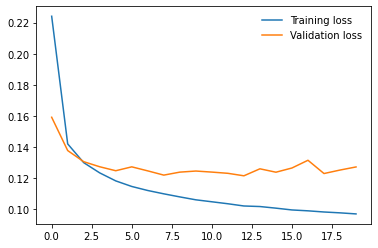

In [12]:
#collapse-hide
plt.plot(train_loss_list, label='Training loss')
plt.plot(test_loss_list, label='Validation loss')
plt.legend(frameon=False)

#### ***Train Accuracy and Validation Accuracy Plots***

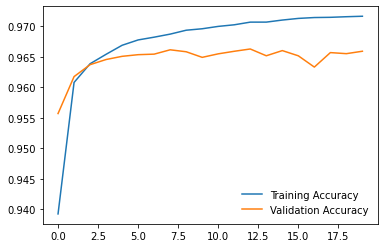

In [13]:
#collapse-hide
plt.plot(train_acc_list, label='Training Accuracy')
plt.plot(test_acc_list, label='Validation Accuracy')
plt.legend(frameon=False)

### Testing
---
Testing the model by measuring its performance over unseen data. The data is loaded and transformed in the same manner as the training and validation datasets undergoes. Following is the size of Test data.


In [14]:
#collapse-hide
# Reshape and normalize
test_data = test_data.reshape(test_data.shape[0], 1, 28, 28).astype('float32')
test_data /= 255.0

print("Shape of test dataset(Unseen): \n", test_data.shape)

Shape of test dataset(Unseen): 
 (100000, 1, 28, 28)


The test data needs to be converted from numpy array to torch tensors. The tensors then must be loaded using DataLoader. Importing, transforming, and predicting over the data in the following cell.

In [15]:
#collapse-hide
#Testing data
X_TEST_tensor = torch.tensor(test_data)
Y_TEST_tensor = torch.tensor(test_labels)
TEST_TENSOR = TensorDataset(X_TEST_tensor, Y_TEST_tensor)

TEST_LOADER = DataLoader(TEST_TENSOR, batch_size= 128, num_workers = 1,
                         shuffle=True)

model.load_state_dict(torch.load('model.pt'))
test_loss, test_acc, loss_, acc_ = evaluate(model, TEST_LOADER, criterion, device)
print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.2f}%')

Test Loss: 0.122 | Test Acc: 96.68%


## **Dimensionality Reduction**
****

As the name suggests, dimensionality reduction is transformation of data from high dimension space to low dimension space, while trying to retain as much of the information as possible. Dimensionality reduction techniques generally includes PCA or t-SNE. These are mainly used and important dimensionality reduction techniques.

#### ***t-SNE representation of input***
---
t-Distributed Stochastic Neighbor Embedding (t-SNE) is an unsupervised, non-linear technique primarily used for data exploration and visualizing high-dimensional data. This is computationaly costlier, therefore, here I have used only 5000 images.  

In [16]:
#collapse-hide
X = np.reshape(x_train, (x_train.shape[0], 28 * 28))[0:5000]
y = y_train[0:5000]
print("Shape of input data used for t-SNE:", "\nX:", X.shape,"\nY:", y.shape)

Shape of input data used for t-SNE: 
X: (5000, 784) 
Y: (5000,)


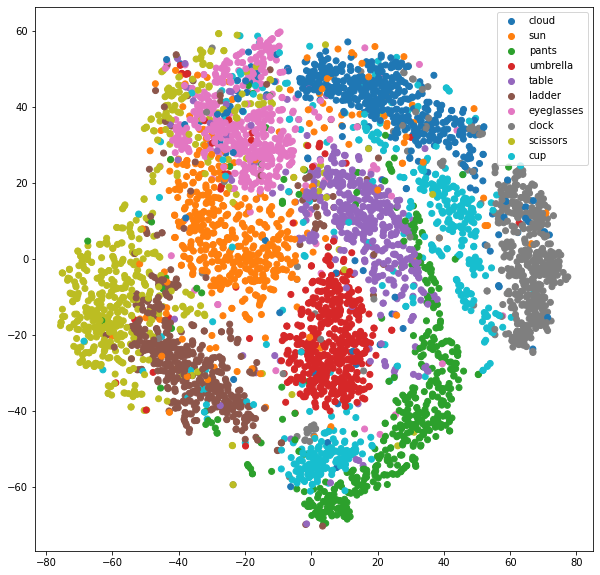

In [17]:
#collapse-hide
out_x = get_tsne(X, n_components=3, n_images= 5000)
plot_representations(out_x, y, class_names, n_images= 5000)

#### ***t-SNE representation of Output***
---
The output representation of 5000 considered images. t-SNE does a good job on separating out the classes.

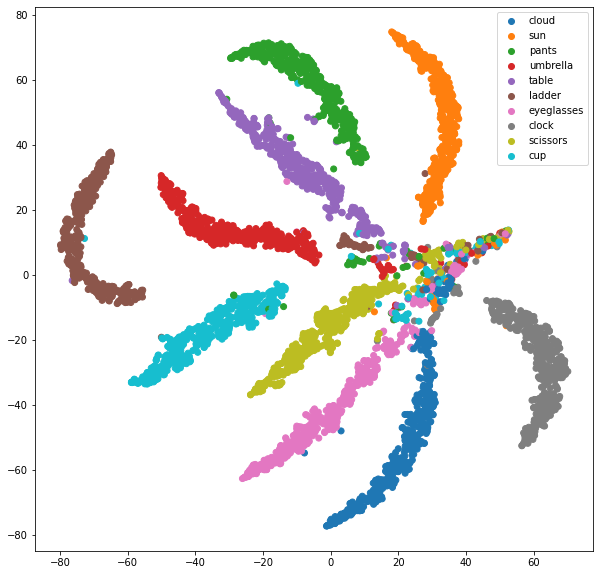

In [47]:
#collapse-hide
N_IMAGES = 5000
outputs, labels = get_representations(model, train_loader, device)
output_tsne_data = get_tsne(outputs, n_images = N_IMAGES)
plot_representations(output_tsne_data, labels, class_names, n_images = N_IMAGES)

#### ***PCA representation***
---
PCA tries to provide maximum number of variables that keeps maximum amount of information about the original data. This contains more of a mathematical operations within it. 

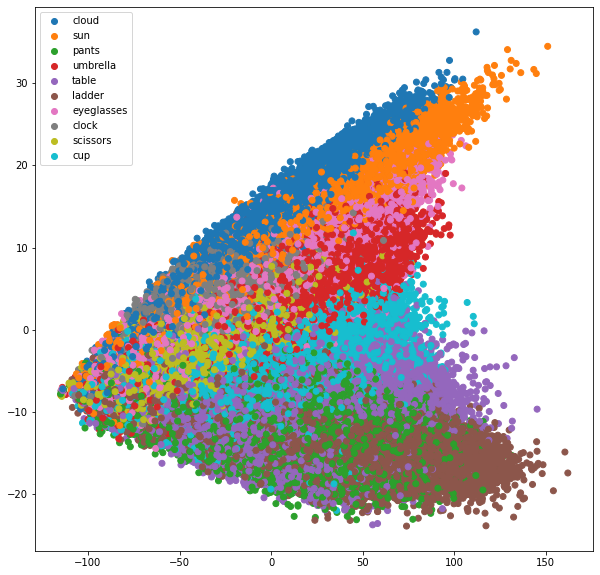

In [19]:
#collapse-hide

output_pca_data = get_pca(outputs)
plot_representations(output_pca_data, labels, class_names)

## Conclusion 
---
Our model performs well and has accuracy of about 96.5%. We also observe the powerful dimensionality reduction techniques, t-SNE and PCA. The dataset is quite big due to which its loading might crash the memory(RAM). This notebook was trained with 12 GB RAM and GPU(Provided by Colab). CNNs are powerful deep neural network architectures that reduce a considerable amount of training parameters, when compared with MLP(Multi Layered Perceptron).  



## References 
---
- Dimensionality Reduction Techniques : Medium post by [Luuk Dersen](https://towardsdatascience.com/visualising-high-dimensional-datasets-using-pca-and-t-sne-in-python-8ef87e7915b)

- Deep Learning by Alfredo Canziani and Yann LeCun : [Course](https://atcold.github.io/pytorch-Deep-Learning/)

- The documents of [Quick Draw Images](https://www.tensorflow.org/datasets/catalog/quickdraw_bitmap)

- Pytorch [Tutorials](https://github.com/pytorch/tutorials)

## ***Thank you***!
